In [1]:
import os

exts = (".jpg", ".jpeg", ".png", ".gif", ".bmp", ".webp")

# List all images under /kaggle/input (change to "/kaggle/working" if needed)
for dirpath, dirnames, filenames in os.walk("/kaggle/input"):
    for f in filenames:
        if f.lower().endswith(exts):
            print(os.path.join(dirpath, f))

/kaggle/input/datasets/shubhangi005/night-images/Capture.PNG
/kaggle/input/datasets/shubhangi005/night-images/Capture2.PNG


# ROI transfer after a camera move — v2 (no road segmentation)

**Goal:** you draw an ROI on image 1 (before the camera was bumped); the notebook predicts where it belongs on image 2.


**How to use:** set the two paths in the next cell → run all → drag the sliders to place the ROI on image 1 (or paste coordinates into `ROI1_MANUAL`) → run the remaining cells.

In [4]:
import os, json
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
%matplotlib inline

IMG1_PATH = '/kaggle/input/datasets/shubhangi005/night-images/Capture.PNG'   # before the move
IMG2_PATH = '/kaggle/input/datasets/shubhangi005/night-images/Capture2.PNG'   # after the move

# Optional: skip the sliders by pasting 4+ (x, y) points, clockwise from top-left.
ROI1_MANUAL    = None     # e.g. [[216,109],[866,109],[866,435],[216,435]]
# Optional: a hand-drawn ROI on image 2, used ONLY to report IoU at the end.
GT_ROI2_MANUAL = None

image 1: (303, 468, 3) | image 2: (332, 475, 3)


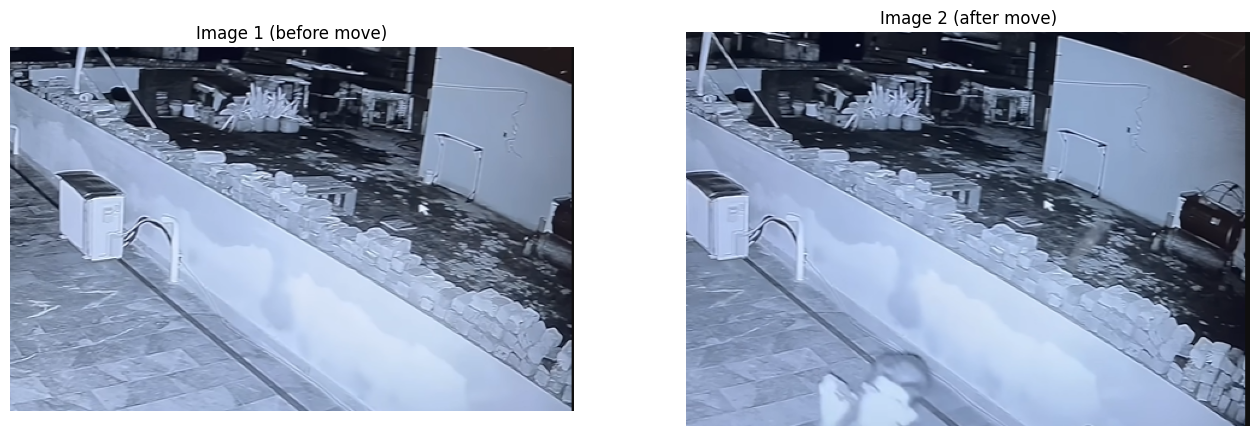

In [5]:
def load_rgb(path):
    im = cv2.imread(path)
    if im is None:
        raise FileNotFoundError(f"Could not read {path}")
    return cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

img1, img2 = load_rgb(IMG1_PATH), load_rgb(IMG2_PATH)
print("image 1:", img1.shape, "| image 2:", img2.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
ax[0].imshow(img1); ax[0].set_title("Image 1 (before move)"); ax[0].axis('off')
ax[1].imshow(img2); ax[1].set_title("Image 2 (after move)");  ax[1].axis('off')
plt.show()

## 1. Pick the ROI on image 1
The picker below reads slider values directly.

In [6]:
class ROIPicker:
    """4-point ROI picker. Call .points() at any time to read the current polygon."""
    def __init__(self, image, title="Adjust ROI", init=None):
        H, W = image.shape[:2]
        self.image, self.title = image, title
        d = np.float32(init if init is not None else
            [[.2*W, .2*H], [.8*W, .2*H], [.8*W, .8*H], [.2*W, .8*H]]).round()
        d[:, 0] = np.clip(d[:, 0], 0, W); d[:, 1] = np.clip(d[:, 1], 0, H)   # sliders can't leave the frame
        self.default = d
        names = ['P1 (TL)', 'P2 (TR)', 'P3 (BR)', 'P4 (BL)']
        mk = lambda v, hi, d: widgets.IntSlider(value=int(v), min=0, max=hi, description=d,
                                                continuous_update=False,
                                                layout=widgets.Layout(width='420px'))
        self.sx = [mk(p[0], W, f'{n} X') for p, n in zip(self.default, names)]
        self.sy = [mk(p[1], H, f'{n} Y') for p, n in zip(self.default, names)]
        self._out = widgets.Output()
        for s in self.sx + self.sy:
            s.observe(self._redraw, names='value')
        display(widgets.VBox([widgets.HBox([a, b]) for a, b in zip(self.sx, self.sy)] + [self._out]))
        self._redraw()

    def points(self):
        return np.float32([[x.value, y.value] for x, y in zip(self.sx, self.sy)])

    def moved(self):
        return not np.allclose(self.points(), self.default)

    def _redraw(self, *_):
        p = self.points()
        with self._out:
            clear_output(wait=True)
            plt.figure(figsize=(11, 6))
            plt.imshow(self.image)
            c = np.vstack([p, p[:1]])
            plt.plot(c[:, 0], c[:, 1], 'r-', lw=3)
            plt.scatter(p[:, 0], p[:, 1], c='lime', s=60, zorder=3)
            for i, (x, y) in enumerate(p):
                plt.text(x + 8, y - 8, f"P{i+1}", color='yellow', fontsize=13, weight='bold')
            plt.title(self.title); plt.axis('off'); plt.show()

picker1 = None
if ROI1_MANUAL is None:
    picker1 = ROIPicker(img1, "ROI on Image 1")
else:
    print("Using ROI1_MANUAL; sliders skipped.")

In [7]:
ROI1 = np.float32(ROI1_MANUAL) if ROI1_MANUAL is not None else picker1.points()
if picker1 is not None and not picker1.moved():
    print("NOTE: the ROI is still the default 20%/80% box - move the sliders if that is not what you want.")
print("ROI on image 1:\n", ROI1)

NOTE: the ROI is still the default 20%/80% box - move the sliders if that is not what you want.
ROI on image 1:
 [[ 94.  61.]
 [374.  61.]
 [374. 242.]
 [ 94. 242.]]


## 2. The method
Everything below is self-contained functions; skim the docstrings, then jump to section 3.

### 2a. Helpers

In [8]:
import cv2
import numpy as np

# ----------------------------------------------------------------------------
# helpers
# ----------------------------------------------------------------------------
def to_3x3(M):
    M = np.asarray(M, dtype=np.float64)
    if M.shape == (3, 3):
        return M
    out = np.eye(3)
    out[:2, :] = M
    return out


def apply_H(H, pts):
    pts = np.asarray(pts, dtype=np.float64).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(pts, to_3x3(H)).reshape(-1, 2)


def poly_area(p):
    return abs(cv2.contourArea(np.asarray(p, dtype=np.float32)))


def polygon_iou(p1, p2, shape):
    m1 = np.zeros(shape[:2], np.uint8)
    m2 = np.zeros(shape[:2], np.uint8)
    cv2.fillPoly(m1, [np.round(p1).astype(np.int32)], 255)
    cv2.fillPoly(m2, [np.round(p2).astype(np.int32)], 255)
    inter = np.logical_and(m1 > 0, m2 > 0).sum()
    union = np.logical_or(m1 > 0, m2 > 0).sum()
    return float(inter / union) if union else 0.0


def preprocess(img_rgb):
    """CLAHE-equalised gray: tames dry-vs-wet asphalt and exposure changes."""
    g = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    return cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8)).apply(g)


def edge_map(gray, sigma=1.5):
    """Smooth gradient-magnitude image. Much less sensitive to lighting than raw
    intensity and gives a smooth objective for ZNCC / ECC."""
    g = cv2.GaussianBlur(gray.astype(np.float32), (0, 0), sigma)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    m = cv2.magnitude(gx, gy)
    return m / (m.max() + 1e-6)

### 2b. Feature matching
SIFT on CLAHE-equalised gray (handles the dry-vs-wet asphalt / exposure change). Matches must survive the ratio test **and** be mutual best matches, then are capped per grid cell so no single busy area dominates the fit.

In [9]:
# ----------------------------------------------------------------------------
# 1. feature matching (SIFT, ratio test + mutual check + spatial spreading)
# ----------------------------------------------------------------------------
def match_features(g1, g2, max_features=8000, ratio=0.8, grid=8, per_cell=10):
    sift = cv2.SIFT_create(nfeatures=max_features, contrastThreshold=0.02)
    kp1, d1 = sift.detectAndCompute(g1, None)
    kp2, d2 = sift.detectAndCompute(g2, None)
    if d1 is None or d2 is None or len(kp1) < 8 or len(kp2) < 8:
        raise RuntimeError("Too few features detected.")

    bf = cv2.BFMatcher(cv2.NORM_L2)
    f = bf.knnMatch(d1, d2, k=2)
    b = bf.knnMatch(d2, d1, k=1)
    back = {m[0].queryIdx: m[0].trainIdx for m in b if m}
    good = [m for m, n in f
            if m.distance < ratio * n.distance and back.get(m.trainIdx) == m.queryIdx]

    # cap matches per grid cell so the fit is not dominated by one busy region
    H_, W_ = g1.shape[:2]
    ch, cw = H_ / grid, W_ / grid
    counts, kept = {}, []
    for m in sorted(good, key=lambda m: m.distance):
        x, y = kp1[m.queryIdx].pt
        c = (int(y // ch), int(x // cw))
        if counts.get(c, 0) < per_cell:
            kept.append(m)
            counts[c] = counts.get(c, 0) + 1
    if len(kept) < 8:
        raise RuntimeError(f"Only {len(kept)} usable matches.")
    src = np.float32([kp1[m.queryIdx].pt for m in kept])
    dst = np.float32([kp2[m.trainIdx].pt for m in kept])
    return src, dst, kp1, kp2, kept

### 2c. Candidate motion models
Similarity (4 DOF), affine (6 DOF) and homography (8 DOF), each fitted with RANSAC/MAGSAC. We keep all three and let the alignment score decide, preferring the simpler model unless the extra freedom really pays off.

In [10]:
# ----------------------------------------------------------------------------
# 2. candidate motion models
# ----------------------------------------------------------------------------
def fit_model(kind, src, dst, thr=3.0):
    s, d = src.reshape(-1, 1, 2), dst.reshape(-1, 1, 2)
    if kind == "similarity":
        M, m = cv2.estimateAffinePartial2D(s, d, method=cv2.RANSAC, ransacReprojThreshold=thr)
    elif kind == "affine":
        M, m = cv2.estimateAffine2D(s, d, method=cv2.RANSAC, ransacReprojThreshold=thr)
    elif kind == "homography":
        M, m = cv2.findHomography(s, d, cv2.USAC_MAGSAC, thr)
    else:
        raise ValueError(kind)
    if M is None:
        return None, None
    return to_3x3(M), m.ravel().astype(bool)


def refit_lsq(kind, src, dst):
    """Least-squares refit on inliers only (used for bootstrap)."""
    s, d = src.reshape(-1, 1, 2), dst.reshape(-1, 1, 2)
    if kind == "homography":
        M, _ = cv2.findHomography(s, d, 0)
    elif kind == "affine":
        M, _ = cv2.estimateAffine2D(s, d, method=cv2.LMEDS)
    else:
        M, _ = cv2.estimateAffinePartial2D(s, d, method=cv2.LMEDS)
    return None if M is None else to_3x3(M)

### 2d. Direct refinement (ECC)
Feature matches can only be as accurate as keypoint localisation. ECC then adjusts the homography to maximise correlation of the *edge maps* over the whole image (or over just the ROI's surroundings), coarse-to-fine over 3 pyramid levels.

In [11]:
# ----------------------------------------------------------------------------
# 3. ECC refinement (direct, intensity-free-ish alignment on edge maps)
# ----------------------------------------------------------------------------
def ecc_refine(e1, e2, M12, mask2=None, levels=3, iters=80, eps=1e-6):
    """Refine a homography img1->img2 with ECC, coarse-to-fine.
    OpenCV's ECC solves template(x) ~ input(W x) with template=img2, input=img1,
    so W maps img2 -> img1 coordinates, i.e. W = inv(M12)."""
    W = np.linalg.inv(to_3x3(M12)).astype(np.float32)
    H_, W_ = e2.shape[:2]
    for lv in reversed(range(levels)):
        s = 1.0 / (2 ** lv)
        a = cv2.resize(e1, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
        b = cv2.resize(e2, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
        mk = None
        if mask2 is not None:
            mk = cv2.resize(mask2, (b.shape[1], b.shape[0]), interpolation=cv2.INTER_NEAREST)
        S = np.diag([s, s, 1.0]).astype(np.float32)
        Wl = S @ W @ np.linalg.inv(S)
        crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iters, eps)
        try:
            cc, Wl = cv2.findTransformECC(b, a, Wl.astype(np.float32),
                                          cv2.MOTION_HOMOGRAPHY, crit, mk, 5)
        except cv2.error:
            return None, None
        W = (np.linalg.inv(S) @ Wl @ S).astype(np.float32)
    return np.linalg.inv(W.astype(np.float64)), float(cc)

### 2e. Scoring and sanity checks (no ground truth needed)
`alignment_score` warps image 1's edge map into image 2 and correlates it with image 2's edge map **in the neighbourhood of the ROI** — i.e. it asks the question that actually matters: *does the scene around my ROI line up?* `sanity` throws out transforms that collapse, explode, flip or send the ROI off-frame.

In [12]:
# ----------------------------------------------------------------------------
# 4. ground-truth-free scoring + sanity checks
# ----------------------------------------------------------------------------
def roi_neighbourhood_mask(roi, shape, grow=0.35):
    """ROI polygon dilated by a fraction of its size - the context around the ROI."""
    m = np.zeros(shape[:2], np.uint8)
    cv2.fillPoly(m, [np.round(roi).astype(np.int32)], 255)
    r = max(3, int(grow * np.sqrt(poly_area(roi))))
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * r + 1, 2 * r + 1))
    return cv2.dilate(m, k)


def alignment_score(e1, e2, M12, roi1, grow=0.35):
    """Zero-normalised cross-correlation between warped img1 edges and img2 edges,
    measured only in the neighbourhood of the ROI. Needs NO ground truth."""
    H_, W_ = e2.shape[:2]
    m1 = roi_neighbourhood_mask(roi1, e1.shape, grow)
    warped = cv2.warpPerspective(e1, M12, (W_, H_), flags=cv2.INTER_LINEAR)
    wm = cv2.warpPerspective(m1, M12, (W_, H_), flags=cv2.INTER_NEAREST) > 0
    valid = cv2.warpPerspective(np.ones_like(e1), M12, (W_, H_), flags=cv2.INTER_NEAREST) > 0
    sel = wm & valid
    if sel.sum() < 500:
        return -1.0
    a, b = warped[sel], e2[sel]
    a, b = a - a.mean(), b - b.mean()
    den = np.sqrt((a * a).sum() * (b * b).sum())
    return float((a * b).sum() / den) if den > 1e-9 else -1.0


def sanity(M12, roi1, shape, area_range=(0.3, 3.5)):
    """Reject transforms that collapse, explode, flip, or leave the frame."""
    if M12 is None or not np.all(np.isfinite(M12)):
        return False, "non-finite"
    out = apply_H(M12, roi1)
    if not np.all(np.isfinite(out)):
        return False, "non-finite ROI"
    a0, a1 = poly_area(roi1), poly_area(out)
    if a0 <= 0:
        return False, "empty source ROI"
    r = a1 / a0
    if not (area_range[0] <= r <= area_range[1]):
        return False, f"ROI area x{r:.2f}"
    s0 = np.sign(cv2.contourArea(roi1.astype(np.float32), True))
    s1 = np.sign(cv2.contourArea(out.astype(np.float32), True))
    if s0 != s1:
        return False, "ROI flipped"
    H_, W_ = shape[:2]
    inside = ((out[:, 0] > -0.5 * W_) & (out[:, 0] < 1.5 * W_) &
              (out[:, 1] > -0.5 * H_) & (out[:, 1] < 1.5 * H_)).all()
    if not inside:
        return False, "ROI far off-frame"
    return True, f"ok (area x{r:.2f})"

### 2f. Uncertainty
Re-fit the transform on bootstrap resamples of the inlier matches and see how far the predicted corners move. Small spread = the matches agree on the answer.

In [13]:
# ----------------------------------------------------------------------------
# 5. bootstrap uncertainty
# ----------------------------------------------------------------------------
def bootstrap_roi(kind, src_in, dst_in, roi1, shape, n=200, seed=0):
    rng = np.random.default_rng(seed)
    outs = []
    N = len(src_in)
    for _ in range(n):
        idx = rng.integers(0, N, N)
        M = refit_lsq(kind, src_in[idx], dst_in[idx])
        if M is None:
            continue
        ok, _ = sanity(M, roi1, shape)
        if ok:
            outs.append(apply_H(M, roi1))
    return np.array(outs)

### 2g. The pipeline

In [1]:
# ____________________________________________________________________________
# whole pileline
# ----------------------------------------------------------------------------
def transfer_roi(img1, img2, roi1, grow=0.35, simple_tolerance=0.01, verbose=True):
    roi1 = np.asarray(roi1, dtype=np.float32)
    g1, g2 = preprocess(img1), preprocess(img2)
    e1, e2 = edge_map(g1), edge_map(g2)

    src, dst, kp1, kp2, matches = match_features(g1, g2)
    if verbose:
        print(f"{len(matches)} mutual, spatially-spread SIFT matches")

    cands = []      # (name, M12, score, ok, msg, extra)
    inl = {}
    for kind in ["similarity", "affine", "homography"]:
        M, mask = fit_model(kind, src, dst)
        if M is None:
            continue
        ok, msg = sanity(M, roi1, img2.shape)
        sc = alignment_score(e1, e2, M, roi1, grow) if ok else -1.0
        cands.append((kind, M, sc, ok, msg, int(mask.sum())))
        inl[kind] = mask

    # direct refinement of the best feature-based homography (or affine fallback)
    seed = next((c for c in cands if c[0] == "homography" and c[3]), None) \
        or next((c for c in cands if c[3]), None)
    if seed is not None:
        m2 = roi_neighbourhood_mask(apply_H(seed[1], roi1).astype(np.float32),
                                    img2.shape, grow + 0.4)
        for tag, mk in [("+ECC (global)", None), ("+ECC (ROI-focused)", m2)]:
            Mr, cc = ecc_refine(e1, e2, seed[1], mask2=mk)
            if Mr is None:
                continue
            ok, msg = sanity(Mr, roi1, img2.shape)
            sc = alignment_score(e1, e2, Mr, roi1, grow) if ok else -1.0
            cands.append((seed[0] + tag, Mr, sc, ok, msg, None))

    # choose: highest score, but prefer the simpler model unless the gain is real
    best = None
    for c in cands:
        if not c[3]:
            continue
        if best is None or c[2] > best[2] + simple_tolerance:
            best = c
    if best is None:
        raise RuntimeError("All candidate transforms were rejected by the sanity checks.")

    if verbose:
        print(f"\n{'model':28s} {'score':>7s}  {'inliers':>7s}  status")
        for c in cands:
            star = "  <== chosen" if c is best else ""
            print(f"{c[0]:28s} {c[2]:7.3f}  {str(c[5] if c[5] is not None else '-'):>7s}  {c[4]}{star}")

    pred = apply_H(best[1], roi1)

    # uncertainty from bootstrapping the feature inliers
    base_kind = best[0].split("+")[0].strip()
    boot = np.empty((0, len(roi1), 2))
    if base_kind in inl:
        mk = inl[base_kind]
        boot = bootstrap_roi(base_kind, src[mk], dst[mk], roi1, img2.shape)
    unc = None
    if len(boot) > 5:
        dev = np.linalg.norm(boot - pred[None], axis=2)          # (n, corners)
        unc = dict(mean_px=float(dev.mean()), p95_px=float(np.percentile(dev, 95)),
                   iou_mean=float(np.mean([polygon_iou(pred, b, img2.shape) for b in boot])))

    # coverage of the inliers (a fit from one corner of the image is not trustworthy)
    cov = None
    if base_kind in inl:
        pts = src[inl[base_kind]]
        if len(pts) >= 3:
            hull = cv2.convexHull(pts.astype(np.float32))
            cov = float(cv2.contourArea(hull) / (img1.shape[0] * img1.shape[1]))

    return dict(pred=pred, M12=best[1], model=best[0], score=best[2],
                boot=boot, uncertainty=unc, coverage=cov, candidates=cands,
                src=src, dst=dst, inlier_masks=inl, e1=e1, e2=e2)

## 3. Run it

In [15]:
result = transfer_roi(img1, img2, ROI1)
PRED_ROI2 = result['pred']
print("\nPredicted ROI on image 2:\n", PRED_ROI2.round(1))

380 mutual, spatially-spread SIFT matches

model                          score  inliers  status
similarity                     0.809      335  ok (area x1.03)
affine                         0.887      366  ok (area x1.03)
homography                     0.945      374  ok (area x1.03)  <== chosen
homography+ECC (global)        0.946        -  ok (area x1.03)

Predicted ROI on image 2:
 [[ 51.   73.8]
 [334.6  70.3]
 [340.8 254.9]
 [ 54.3 256.4]]


In [16]:
def verdict(res, img_shape):
    """Simple traffic-light summary. Thresholds are heuristics - treat them as a prompt to look, not a proof."""
    notes, level = [], "GOOD"
    diag = float(np.hypot(*img_shape[:2]))
    kind = res['model'].split('+')[0].strip()
    n_in = int(res['inlier_masks'][kind].sum()) if kind in res['inlier_masks'] else 0
    if n_in < 15:                       notes.append(f"only {n_in} inlier matches");             level = "CHECK"
    if res['coverage'] is not None and res['coverage'] < 0.10:
                                        notes.append(f"inliers cover only {res['coverage']:.0%} of the frame"); level = "CHECK"
    u = res['uncertainty']
    if u is None:                       notes.append("bootstrap unavailable");                  level = "CHECK"
    elif u['p95_px'] > 0.02 * diag:     notes.append(f"corner uncertainty p95 = {u['p95_px']:.1f}px"); level = "CHECK"
    if res['score'] < 0.10:             notes.append(f"weak alignment score {res['score']:.2f}"); level = "CHECK"
    return level, notes

level, notes = verdict(result, img2.shape)
u = result['uncertainty']
print(f"Model chosen : {result['model']}")
print(f"Align score  : {result['score']:.3f}")
if u: print(f"Uncertainty  : mean {u['mean_px']:.1f}px, p95 {u['p95_px']:.1f}px, bootstrap IoU {u['iou_mean']:.3f}")
if result['coverage'] is not None: print(f"Inlier cover : {result['coverage']:.0%} of frame area")
print(f"Verdict      : {level}" + (" - " + "; ".join(notes) if notes else ""))

Model chosen : homography
Align score  : 0.945
Uncertainty  : mean 0.1px, p95 0.1px, bootstrap IoU 1.000
Inlier cover : 76% of frame area
Verdict      : GOOD


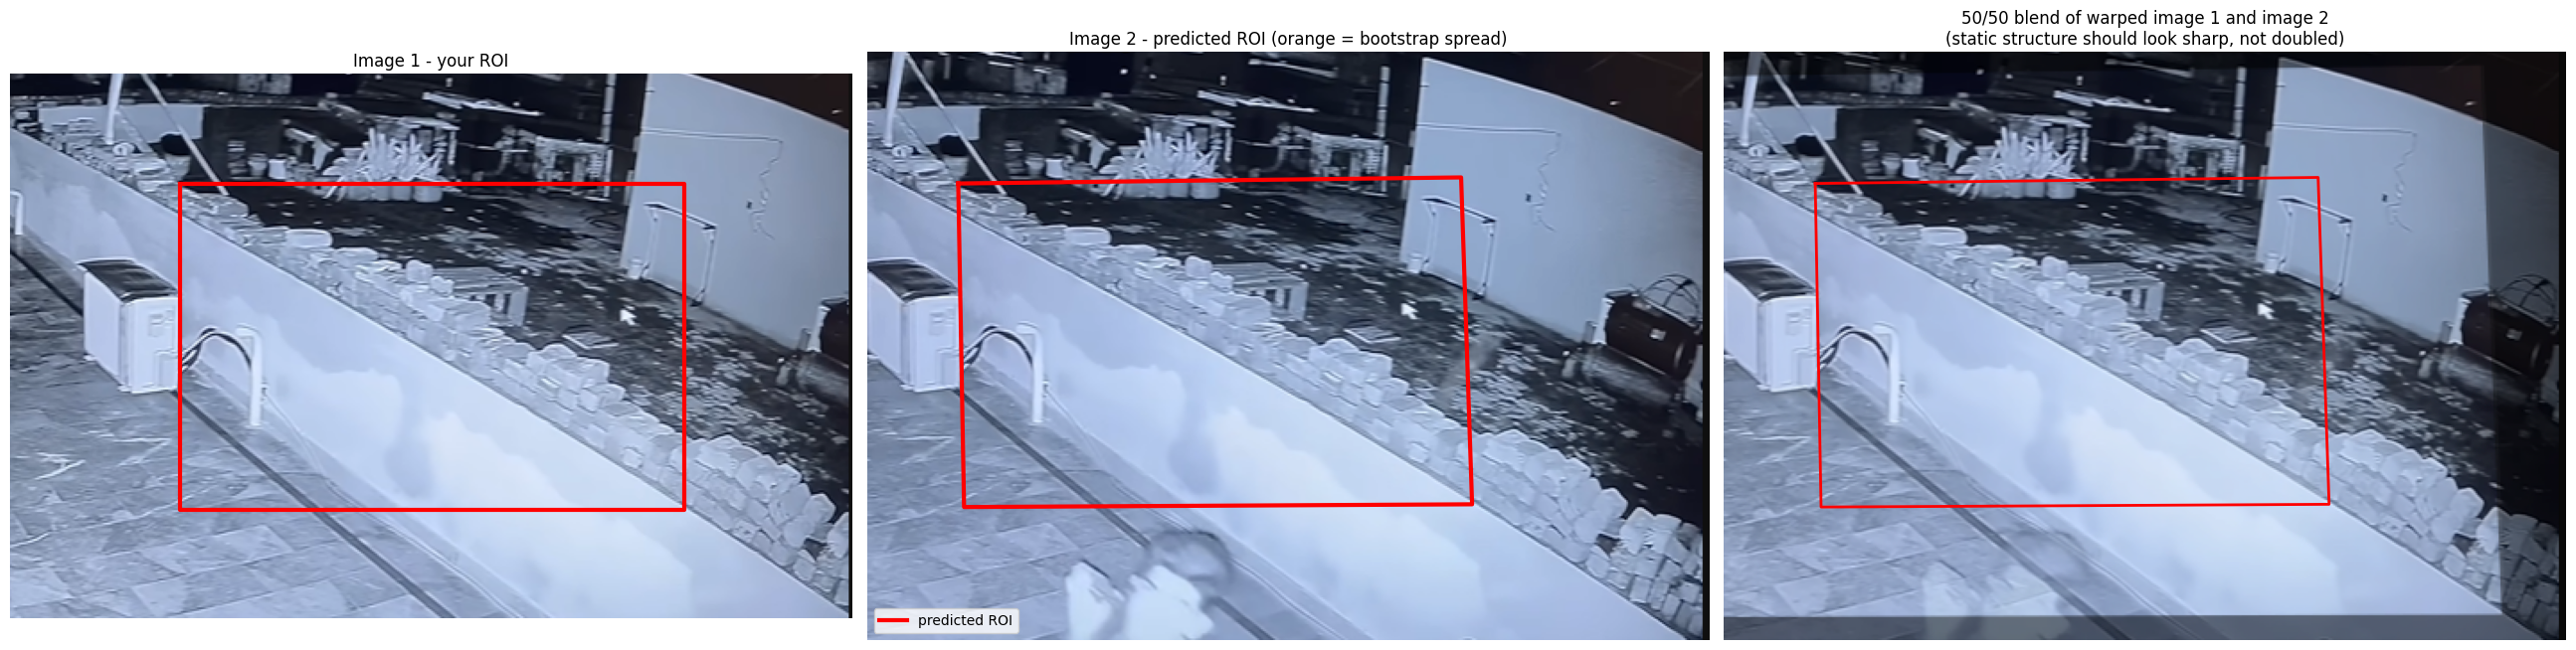

In [17]:
def closed(p): return np.vstack([p, p[:1]])

def show_result(img1, img2, roi1, res, gt2=None):
    pred, M = res['pred'], res['M12']
    fig, ax = plt.subplots(1, 3, figsize=(26, 7))

    ax[0].imshow(img1); ax[0].plot(*closed(roi1).T, 'r-', lw=3)
    ax[0].set_title("Image 1 - your ROI")

    ax[1].imshow(img2)
    for b in res['boot'][:60]:                       # ghost outlines = uncertainty
        ax[1].plot(*closed(b).T, color='orange', lw=0.6, alpha=0.25)
    ax[1].plot(*closed(pred).T, 'r-', lw=3, label='predicted ROI')
    if gt2 is not None:
        ax[1].plot(*closed(gt2).T, 'g--', lw=3, label='hand-drawn (validation)')
    ax[1].legend(loc='lower left'); ax[1].set_title("Image 2 - predicted ROI (orange = bootstrap spread)")

    warped = cv2.warpPerspective(img1, M, (img2.shape[1], img2.shape[0]))
    ax[2].imshow(cv2.addWeighted(warped, 0.5, img2, 0.5, 0))
    ax[2].plot(*closed(pred).T, 'r-', lw=2)
    ax[2].set_title("50/50 blend of warped image 1 and image 2\n(static structure should look sharp, not doubled)")
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()

show_result(img1, img2, ROI1, result)

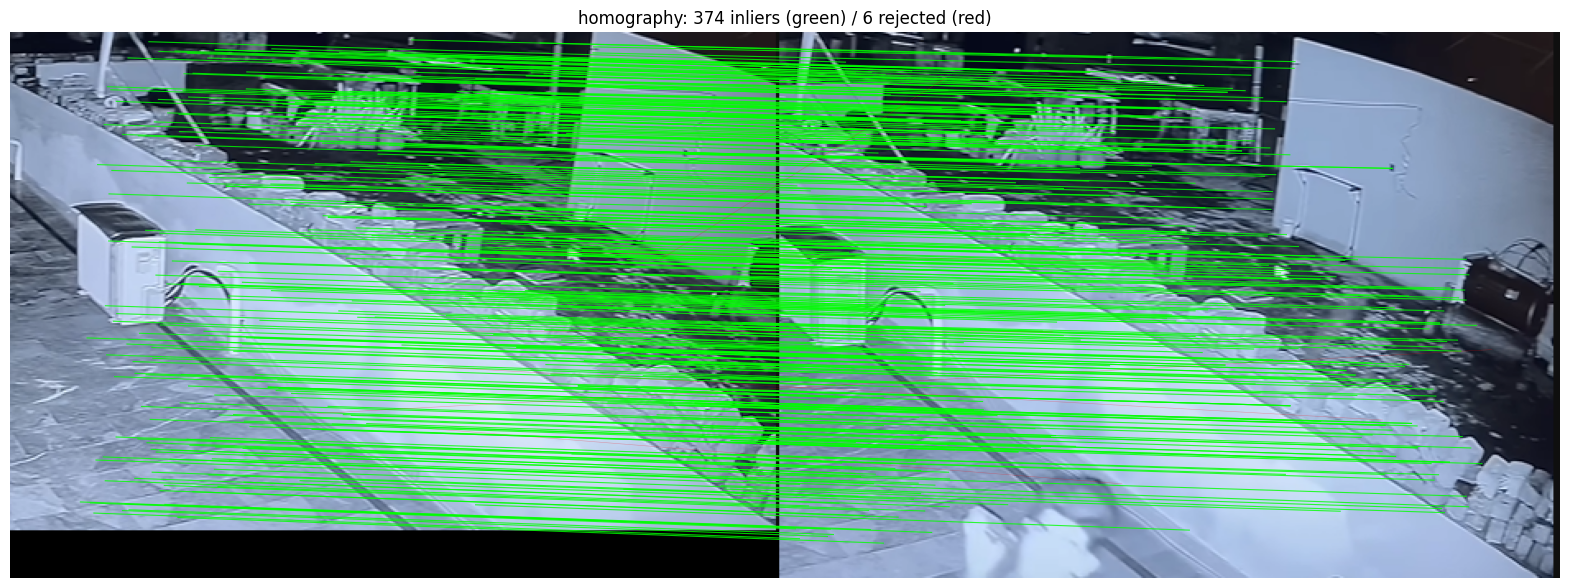

In [18]:
def show_matches(img1, img2, res):
    kind = res['model'].split('+')[0].strip()
    m = res['inlier_masks'].get(kind)
    if m is None: return
    h = max(img1.shape[0], img2.shape[0])
    pad = lambda im: np.pad(im, ((0, h - im.shape[0]), (0, 0), (0, 0)))
    canvas = np.hstack([pad(img1), pad(img2)]); off = img1.shape[1]
    plt.figure(figsize=(20, 8)); plt.imshow(canvas)
    for (x1, y1), (x2, y2), ok in zip(res['src'], res['dst'], m):
        plt.plot([x1, x2 + off], [y1, y2], '-', color='lime' if ok else 'red',
                 lw=0.8 if ok else 0.4, alpha=0.8 if ok else 0.3)
    plt.title(f"{kind}: {int(m.sum())} inliers (green) / {int((~m).sum())} rejected (red)")
    plt.axis('off'); plt.show()

show_matches(img1, img2, result)

## 4. Optional validation against a hand-drawn ROI on image 2
Set `GT_ROI2_MANUAL` in the config cell, or use the picker below. This is only to *report* accuracy - nothing above uses it.

In [19]:
picker2 = None
if GT_ROI2_MANUAL is None:
    picker2 = ROIPicker(img2, "Hand-drawn ROI on Image 2 (validation only)", init=PRED_ROI2)

In [20]:
GT_ROI2 = np.float32(GT_ROI2_MANUAL) if GT_ROI2_MANUAL is not None else (
          picker2.points() if (picker2 is not None and picker2.moved()) else None)

if GT_ROI2 is None:
    print("No ground-truth ROI supplied - skipping validation.")
else:
    iou = polygon_iou(PRED_ROI2, GT_ROI2, img2.shape)
    err = np.linalg.norm(PRED_ROI2 - GT_ROI2, axis=1)
    print(f"IoU vs hand-drawn ROI : {iou:.3f}")
    print(f"Corner error (px)     : mean {err.mean():.1f}, max {err.max():.1f}")
    show_result(img1, img2, ROI1, result, gt2=GT_ROI2)

No ground-truth ROI supplied - skipping validation.


## 5. Save the result

In [21]:
out_dir = '/kaggle/working' if os.path.isdir('/kaggle/working') else '.'
out = dict(roi_image1=ROI1.tolist(), roi_image2_predicted=PRED_ROI2.tolist(),
           model=result['model'], homography_img1_to_img2=result['M12'].tolist(),
           alignment_score=result['score'], uncertainty=result['uncertainty'],
           verdict=level)
path = os.path.join(out_dir, 'roi_result.json')
with open(path, 'w') as f:
    json.dump(out, f, indent=2)
print("saved", path)

saved /kaggle/working/roi_result.json


ACCURACY CHECK

A. Synthetic ground truth: 15 random camera bumps applied to YOUR image 1,
   with lighting change, blur, noise and fake moving objects. Error = mean ROI-corner error (px).
Caching image-1 features once (this used to be redone every trial)...
  trial 1/15 done (1.0s elapsed)
  trial 2/15 done (2.2s elapsed)
  trial 3/15 done (3.4s elapsed)
  trial 4/15 done (4.3s elapsed)
  trial 5/15 done (5.3s elapsed)
  trial 6/15 done (6.3s elapsed)
  trial 7/15 done (7.5s elapsed)
  trial 8/15 done (9.3s elapsed)
  trial 9/15 done (10.4s elapsed)
  trial 10/15 done (11.6s elapsed)
  trial 11/15 done (12.9s elapsed)
  trial 12/15 done (14.0s elapsed)
  trial 13/15 done (15.0s elapsed)
  trial 14/15 done (16.0s elapsed)
  trial 15/15 done (17.1s elapsed)
   v2 (this notebook): mean 0.13 | median 0.11 | p95 0.24 | max 0.32
                       IoU mean 0.998, worst 0.995, failures 0/15
   v1 (ORB+similarity): mean 1.09 | median 1.11 | p95 1.95 | max 2.32
                       IoU m

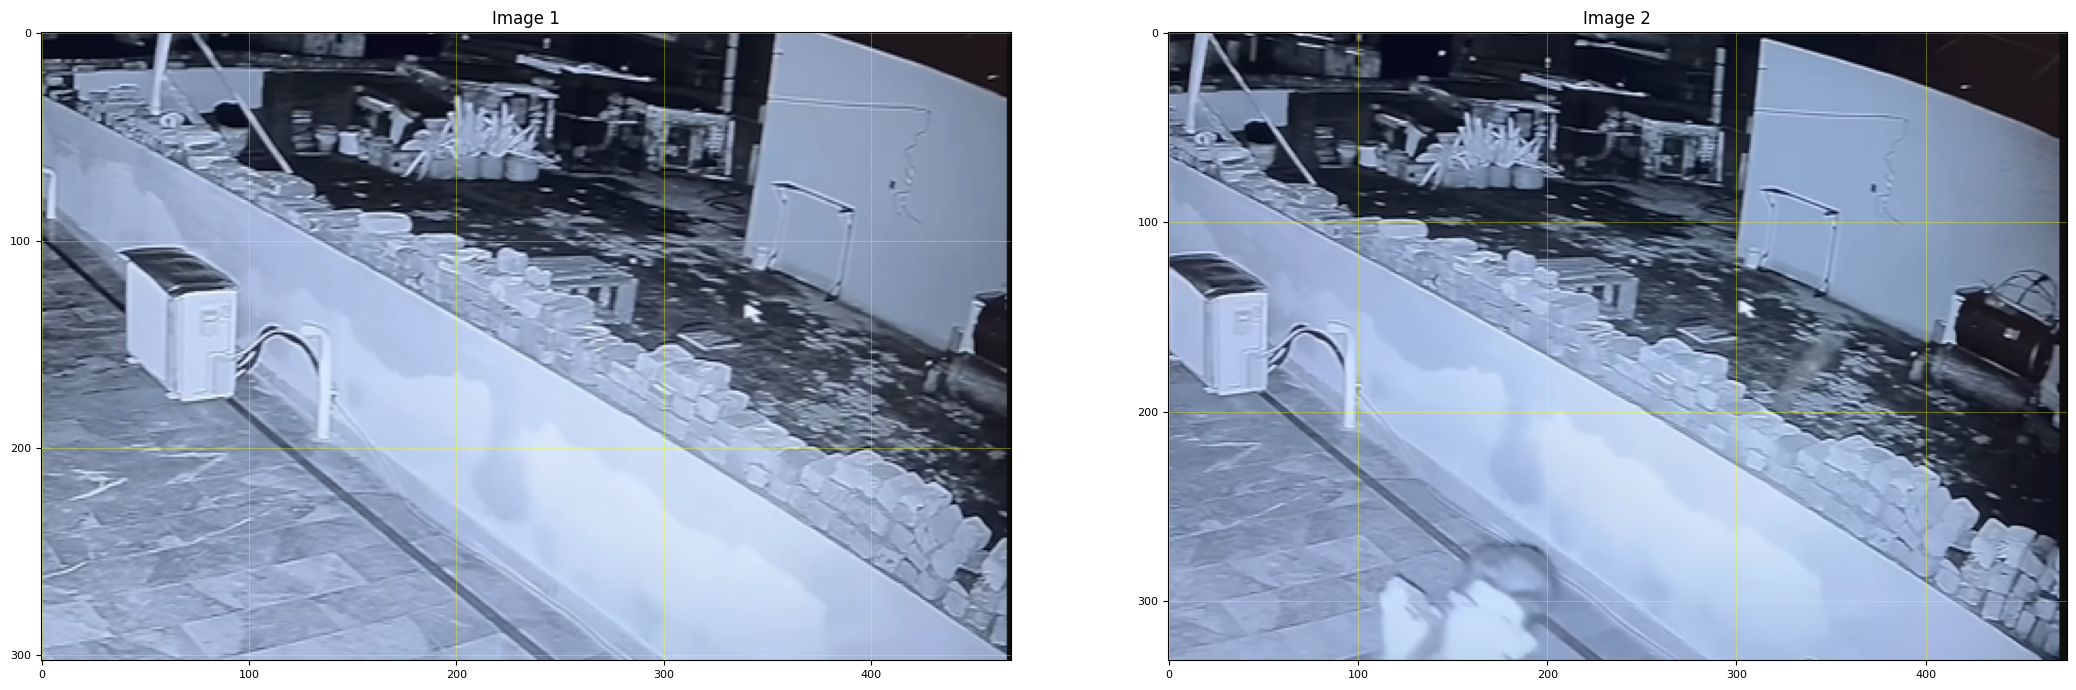


C. Round trip (image 1 -> 2 -> 1): consistency, not absolute accuracy.
   corner error after the round trip (px): mean 0.02 | median 0.02 | p95 0.03 | max 0.03
   IoU with the original ROI: 1.000

---------------------------------------------------------------- 
How to read this
  * Synthetic bumps (check A): median 0.11px, p95 0.24px ROI-corner error. This is a best case - real scenes are harder.
  * Round-trip error 0.0px: small = the estimate is self-consistent; it cannot catch a shared bias.
  * Check A is easier than reality (one source image, no parallax). If B is much worse than A,
    suspect moving objects, depth/parallax, or landmarks that are not on static structure.


In [22]:
# ============================== ACCURACY CHECK (fast) ==============================
# Three independent checks. A and C need nothing from you; B is the only one that
# measures accuracy on the REAL image pair, so it is the most convincing.
#
# FIX vs the previous version: check A used to call transfer_roi() inside the loop,
# which recomputed image 1's CLAHE/edge-map/SIFT features from scratch on every
# trial even though image 1 never changes. That silent, repeated work is what made
# the cell look hung and got it KeyboardInterrupt-ed. This version computes image
# 1's features ONCE, reuses them for every trial, and prints progress per trial.
import time

N_TRIALS   = 15      # synthetic trials for check A
SEED       = 0
SIFT_NFEATURES_CHECK = 3000   # lighter than the main run's 8000 - plenty for this check
# Check B (optional): the same STATIC point in both images, as [x1, y1, x2, y2].
# Use 4-8 well-spread points: sign corners, pole bases, container corners, road-edge
# kinks... NOT vehicles/people. Leave as None to print a grid to read coordinates from.
LANDMARKS = None    # e.g. [[812,455, 790,470], [301,120, 288,141], ...]


def _random_bump(W, H, mag, rng):
    """A random camera-bump-like homography: rotation, scale, shift and a little tilt/pan."""
    ang = np.deg2rad(rng.uniform(-mag, mag)); sc = 1 + rng.uniform(-.05, .05) * mag / 2
    tx, ty = rng.uniform(-.06, .06, 2) * np.array([W, H]) * mag / 2
    px, py = rng.uniform(-4e-5, 4e-5, 2) * mag / 2 * (1000.0 / max(W, H))
    c, s = np.cos(ang) * sc, np.sin(ang) * sc
    T1 = np.array([[1, 0, -W / 2], [0, 1, -H / 2], [0, 0, 1]])
    T2 = np.array([[1, 0, W / 2 + tx], [0, 1, H / 2 + ty], [0, 0, 1]])
    return T2 @ np.array([[c, -s, 0], [s, c, 0], [px, py, 1]]) @ T1


def _degrade(im, rng):
    """Make the synthetic 'after' image as awkward as the real one: lighting change,
    blur, noise, and a few solid blocks standing in for vehicles/people."""
    h, w = im.shape[:2]
    o = im.astype(np.float32) * rng.uniform(.75, 1.2) + rng.uniform(-15, 15)
    o = cv2.GaussianBlur(np.clip(o, 0, 255), (0, 0), 1.2) + rng.normal(0, 3, im.shape)
    o = np.clip(o, 0, 255).astype(np.uint8)
    for _ in range(3):
        x, y = int(rng.integers(w // 10, w - w // 8)), int(rng.integers(h // 10, h - h // 6))
        cv2.rectangle(o, (x, y), (x + int(rng.integers(w // 30, w // 12)), y + int(rng.integers(h // 14, h // 6))),
                      tuple(int(v) for v in rng.integers(0, 255, 3)), -1)
    return o


def _stats(x):
    x = np.asarray(x, float)
    return f"mean {np.nanmean(x):.2f} | median {np.nanmedian(x):.2f} | p95 {np.nanpercentile(x, 95):.2f} | max {np.nanmax(x):.2f}"


def _match_from_cache(kp1, d1, g2, max_features, ratio, grid, per_cell):
    """Same filtering as match_features(), but image 1's SIFT keypoints/descriptors
    are passed in instead of being recomputed on every call."""
    sift = cv2.SIFT_create(nfeatures=max_features, contrastThreshold=0.02)
    kp2, d2 = sift.detectAndCompute(g2, None)
    if d1 is None or d2 is None or len(kp1) < 8 or len(kp2) < 8:
        raise RuntimeError("Too few features detected.")
    bf = cv2.BFMatcher(cv2.NORM_L2)
    f = bf.knnMatch(d1, d2, k=2)
    b = bf.knnMatch(d2, d1, k=1)
    back = {m[0].queryIdx: m[0].trainIdx for m in b if m}
    good = [m for m, n in f
            if m.distance < ratio * n.distance and back.get(m.trainIdx) == m.queryIdx]
    H_, W_ = g2.shape[:2]
    ch, cw = H_ / grid, W_ / grid
    counts, kept = {}, []
    for m in sorted(good, key=lambda m: m.distance):
        x, y = kp1[m.queryIdx].pt
        c = (int(y // ch), int(x // cw))
        if counts.get(c, 0) < per_cell:
            kept.append(m)
            counts[c] = counts.get(c, 0) + 1
    if len(kept) < 8:
        raise RuntimeError(f"Only {len(kept)} usable matches.")
    src = np.float32([kp1[m.queryIdx].pt for m in kept])
    dst = np.float32([kp2[m.trainIdx].pt for m in kept])
    return src, dst


def _transfer_roi_fast(g1_cache, e1_cache, kp1_cache, d1_cache, im2, roi1,
                        nfeatures=SIFT_NFEATURES_CHECK, grow=0.35, simple_tolerance=0.01):
    """Trimmed transfer_roi() for repeated calls: reuses image 1's grayscale/CLAHE,
    edge map and SIFT features instead of recomputing them every trial."""
    g2 = preprocess(im2)
    e2 = edge_map(g2)
    src, dst = _match_from_cache(kp1_cache, d1_cache, g2, nfeatures, 0.8, 8, 10)

    cands = []
    for kind in ["similarity", "affine", "homography"]:
        M, mask = fit_model(kind, src, dst)
        if M is None:
            continue
        ok, msg = sanity(M, roi1, im2.shape)
        sc = alignment_score(e1_cache, e2, M, roi1, grow) if ok else -1.0
        cands.append((kind, M, sc, ok))

    seed = next((c for c in cands if c[0] == "homography" and c[3]), None) \
        or next((c for c in cands if c[3]), None)
    if seed is not None:
        m2 = roi_neighbourhood_mask(apply_H(seed[1], roi1).astype(np.float32), im2.shape, grow + 0.4)
        for mk in [None, m2]:
            Mr, _ = ecc_refine(e1_cache, e2, seed[1], mask2=mk)
            if Mr is None:
                continue
            ok, _ = sanity(Mr, roi1, im2.shape)
            sc = alignment_score(e1_cache, e2, Mr, roi1, grow) if ok else -1.0
            cands.append(("refined", Mr, sc, ok))

    best = None
    for c in cands:
        if not c[3]:
            continue
        if best is None or c[2] > best[2] + simple_tolerance:
            best = c
    if best is None:
        raise RuntimeError("All candidate transforms were rejected by the sanity checks.")
    return apply_H(best[1], roi1)


def _old_orb_similarity_cached(k1, d1, gray2, orb):
    """Cached-img1-side version of the v1 (ORB + 4-DOF similarity) baseline."""
    k2, d2 = orb.detectAndCompute(gray2, None)
    if d1 is None or d2 is None:
        return None
    m = cv2.BFMatcher(cv2.NORM_HAMMING).knnMatch(d1, d2, k=2)
    good = [x for x, y in (p for p in m if len(p) == 2) if x.distance < 0.75 * y.distance]
    if len(good) < 4:
        return None
    s = np.float32([k1[x.queryIdx].pt for x in good]).reshape(-1, 1, 2)
    d = np.float32([k2[x.trainIdx].pt for x in good]).reshape(-1, 1, 2)
    M, _ = cv2.estimateAffinePartial2D(s, d, method=cv2.RANSAC, ransacReprojThreshold=5.0)
    return to_3x3(M) if M is not None else None


# ---------------------------------------------------------------- A. synthetic (fast)
def check_synthetic_fast(img1, roi1, n_trials, seed):
    rng = np.random.default_rng(seed)
    H_, W_ = img1.shape[:2]

    # cache everything about image 1 ONCE - this is what made 15 trials slow before
    print("Caching image-1 features once (this used to be redone every trial)...", flush=True)
    g1 = preprocess(img1)
    e1 = edge_map(g1)
    sift = cv2.SIFT_create(nfeatures=SIFT_NFEATURES_CHECK, contrastThreshold=0.02)
    kp1, d1 = sift.detectAndCompute(g1, None)
    orb = cv2.ORB_create(4000)
    gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
    ok1, od1 = orb.detectAndCompute(gray1, None)

    rows = []
    t0 = time.time()
    for t in range(n_trials):
        Hg = _random_bump(W_, H_, mag=[1, 2, 3, 4][t % 4], rng=rng)
        im2 = _degrade(cv2.warpPerspective(img1, Hg, (W_, H_), borderMode=cv2.BORDER_REFLECT), rng)
        gt = apply_H(Hg, roi1)
        r = dict(new_err=np.nan, new_iou=0.0, old_err=np.nan, old_iou=0.0)
        try:
            p = _transfer_roi_fast(g1, e1, kp1, d1, im2, roi1)
            r.update(new_err=np.linalg.norm(p - gt, axis=1).mean(), new_iou=polygon_iou(p, gt, im2.shape))
        except Exception:
            pass
        try:
            gray2 = cv2.cvtColor(im2, cv2.COLOR_RGB2GRAY)
            M = _old_orb_similarity_cached(ok1, od1, gray2, orb)
            if M is not None:
                p = apply_H(M, roi1)
                r.update(old_err=np.linalg.norm(p - gt, axis=1).mean(), old_iou=polygon_iou(p, gt, im2.shape))
        except Exception:
            pass
        rows.append(r)
        print(f"  trial {t+1}/{n_trials} done ({time.time()-t0:.1f}s elapsed)", flush=True)
    return rows


# ---------------------------------------------------------------- B. landmarks
def check_landmarks(res, landmarks):
    L = np.float32(landmarks).reshape(-1, 4)
    pred = apply_H(res['M12'], L[:, :2])
    err = np.linalg.norm(pred - L[:, 2:], axis=1)
    return L, pred, err


# ---------------------------------------------------------------- C. round trip
def check_round_trip(img1, img2, roi1, res):
    back = transfer_roi(img2, img1, res['pred'], verbose=False)['pred']
    return back, np.linalg.norm(back - roi1, axis=1), polygon_iou(back, roi1, img1.shape)


# =================================== run ===================================
print("=" * 64, "\nACCURACY CHECK\n" + "=" * 64)

# --- A
print(f"\nA. Synthetic ground truth: {N_TRIALS} random camera bumps applied to YOUR image 1,")
print("   with lighting change, blur, noise and fake moving objects. Error = mean ROI-corner error (px).")
rowsA = check_synthetic_fast(img1, ROI1, N_TRIALS, SEED)
newE, oldE = [r['new_err'] for r in rowsA], [r['old_err'] for r in rowsA]
newI, oldI = [r['new_iou'] for r in rowsA], [r['old_iou'] for r in rowsA]
print(f"   v2 (this notebook): {_stats(newE)}")
print(f"                       IoU mean {np.mean(newI):.3f}, worst {np.min(newI):.3f}, failures {int(np.isnan(newE).sum())}/{N_TRIALS}")
print(f"   v1 (ORB+similarity): {_stats(oldE)}")
print(f"                       IoU mean {np.mean(oldI):.3f}, worst {np.min(oldI):.3f}, failures {int(np.isnan(oldE).sum())}/{N_TRIALS}")

# --- B
print("\nB. Real-image landmarks (the honest measurement on your actual pair):")
if LANDMARKS is None:
    print("   No LANDMARKS given. Read matching static points off the grids below and set LANDMARKS above.")
    fig, ax = plt.subplots(1, 2, figsize=(22, 7))
    for a, im, t in zip(ax, [img1, img2], ["Image 1", "Image 2"]):
        a.imshow(im); a.set_title(t)
        a.set_xticks(range(0, im.shape[1], 100)); a.set_yticks(range(0, im.shape[0], 100))
        a.grid(True, color='yellow', alpha=.4, lw=.6); a.tick_params(labelsize=8)
    plt.tight_layout(); plt.show()
    errB = None
else:
    L, predL, errB = check_landmarks(result, LANDMARKS)
    print(f"   {len(L)} landmarks -> reprojection error (px): {_stats(errB)}")
    if len(L) < 4:
        print("   (fewer than 4 landmarks - treat this as anecdotal)")
    fig, ax = plt.subplots(1, 2, figsize=(22, 7))
    ax[0].imshow(img1); ax[0].scatter(L[:, 0], L[:, 1], c='lime', s=60); ax[0].set_title("Image 1 landmarks")
    ax[1].imshow(img2); ax[1].scatter(L[:, 2], L[:, 3], c='lime', s=70, label='you marked')
    ax[1].scatter(predL[:, 0], predL[:, 1], c='red', marker='x', s=70, label='predicted by the method')
    for (a_, b_), (c_, d_) in zip(L[:, 2:], predL):
        ax[1].plot([a_, c_], [b_, d_], 'y-', lw=1)
    ax[1].legend(); ax[1].set_title("Image 2: marked vs predicted"); [a.axis('off') for a in ax]
    plt.tight_layout(); plt.show()

# --- C
print("\nC. Round trip (image 1 -> 2 -> 1): consistency, not absolute accuracy.")
try:
    back, errC, iouC = check_round_trip(img1, img2, ROI1, result)
    print(f"   corner error after the round trip (px): {_stats(errC)}")
    print(f"   IoU with the original ROI: {iouC:.3f}")
except Exception as e:
    errC, iouC = None, None
    print("   round trip failed:", e)

# --- hand-drawn ROI, if one was supplied in section 4
if 'GT_ROI2' in globals() and GT_ROI2 is not None:
    print(f"\nD. Hand-drawn ROI from section 4: IoU {polygon_iou(PRED_ROI2, GT_ROI2, img2.shape):.3f}")

# --- summary
print("\n" + "-" * 64, "\nHow to read this")
print(f"  * Synthetic bumps (check A): median {np.nanmedian(newE):.2f}px, p95 {np.nanpercentile(newE, 95):.2f}px ROI-corner error."
      f" This is a best case - real scenes are harder.")
if errB is not None:
    print(f"  * On your real pair the landmarks land within {errB.mean():.1f}px on average (check B) - this is the number to trust (if your landmarks are on static structure).")
if errC is not None:
    print(f"  * Round-trip error {np.mean(errC):.1f}px: small = the estimate is self-consistent; it cannot catch a shared bias.")
print("  * Check A is easier than reality (one source image, no parallax). If B is much worse than A,")
print("    suspect moving objects, depth/parallax, or landmarks that are not on static structure.")


In [21]:
import os, cv2, numpy as np, zipfile

out_dir = '/kaggle/working'
os.makedirs(out_dir, exist_ok=True)

def draw_roi(img_rgb, roi, color=(255, 0, 0), thickness=3, label=True):
    """Return a copy of the RGB image with the ROI polygon and corner labels drawn on it."""
    im = img_rgb.copy()
    pts = np.round(roi).astype(np.int32).reshape(-1, 1, 2)
    cv2.polylines(im, [pts], isClosed=True, color=color, thickness=thickness)
    for i, (x, y) in enumerate(pts.reshape(-1, 2)):
        cv2.circle(im, (int(x), int(y)), 6, (0, 255, 0), -1)
        if label:
            cv2.putText(im, f"P{i+1}", (int(x) + 8, int(y) - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 0), 2, cv2.LINE_AA)
    return im

im1_roi = draw_roi(img1, ROI1)
im2_roi = draw_roi(img2, PRED_ROI2)

p1 = os.path.join(out_dir, 'image1_with_ROI.png')
p2 = os.path.join(out_dir, 'image2_with_predicted_ROI.png')

# cv2.imwrite expects BGR, but our arrays are RGB, so convert first
cv2.imwrite(p1, cv2.cvtColor(im1_roi, cv2.COLOR_RGB2BGR))
cv2.imwrite(p2, cv2.cvtColor(im2_roi, cv2.COLOR_RGB2BGR))

# bundle both into one zip for a single download
zp = os.path.join(out_dir, 'roi_images.zip')
with zipfile.ZipFile(zp, 'w') as z:
    z.write(p1, os.path.basename(p1))
    z.write(p2, os.path.basename(p2))

print("Saved:")
for p in (p1, p2, zp):
    print(" ", p, f"({os.path.getsize(p)/1024:.0f} KB)")

Saved:
  /kaggle/working/image1_with_ROI.png (231 KB)
  /kaggle/working/image2_with_predicted_ROI.png (240 KB)
  /kaggle/working/roi_images.zip (471 KB)
